# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# Load Data

In [344]:
data = pd.read_csv('diabetes.csv')

# EDA

In [345]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [346]:
data.shape


(768, 9)

In [347]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Visualization

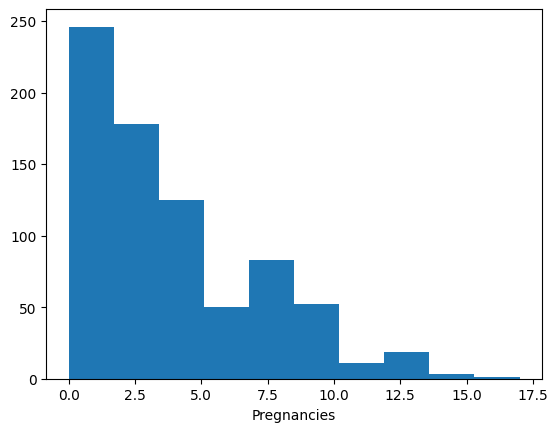

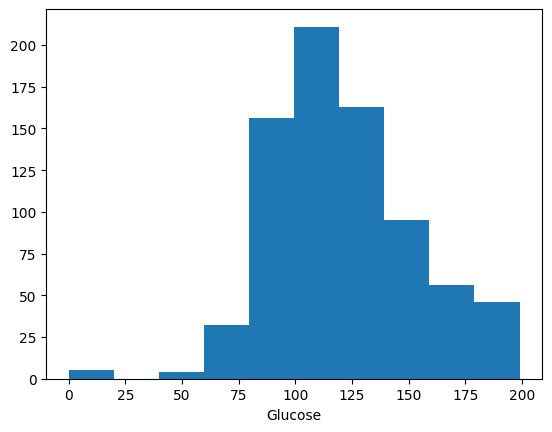

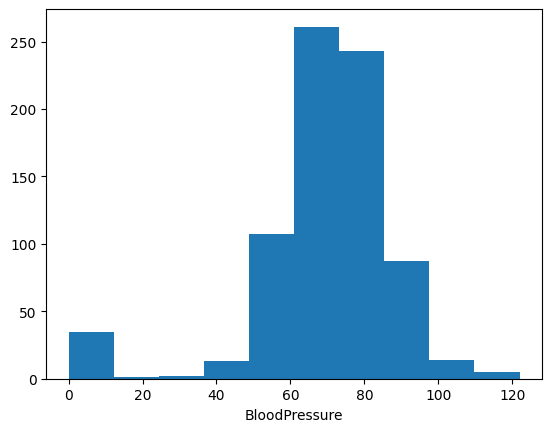

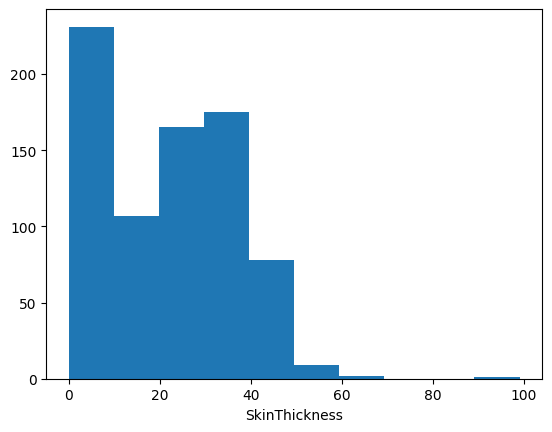

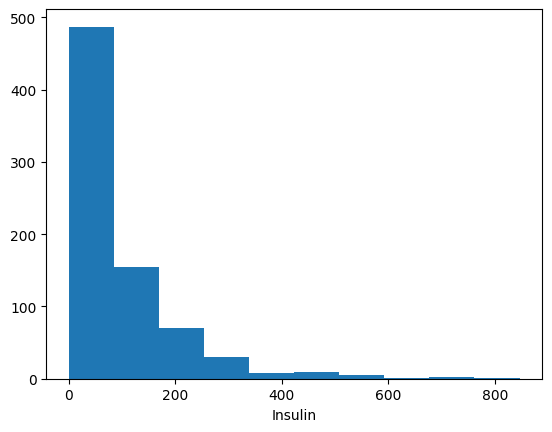

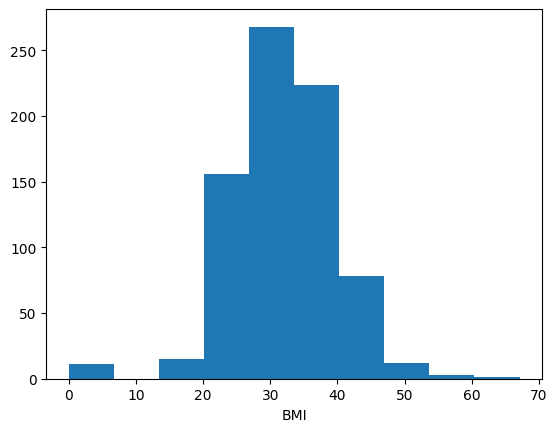

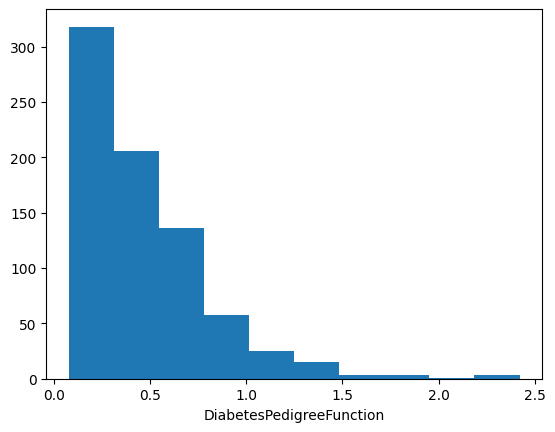

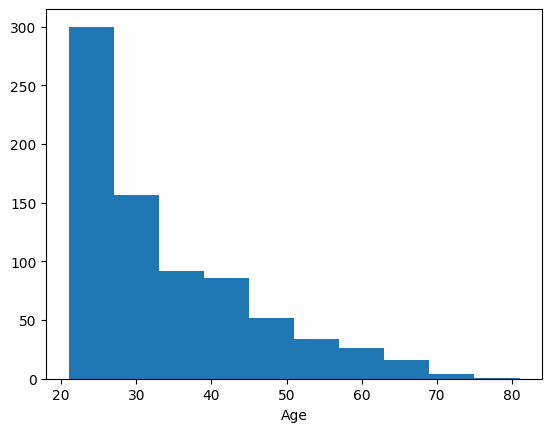

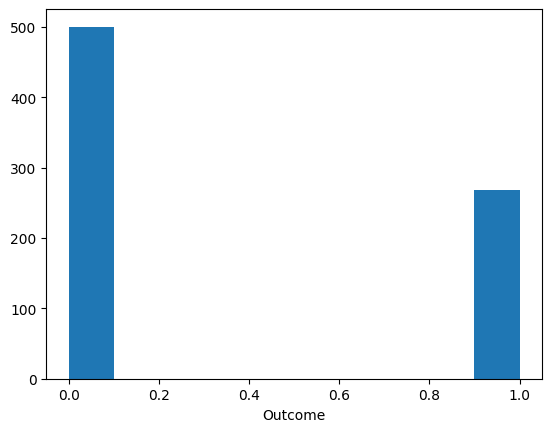

In [348]:
for col in data.columns:
    plt.hist(data[col])
    plt.xlabel(col)
    plt.show()

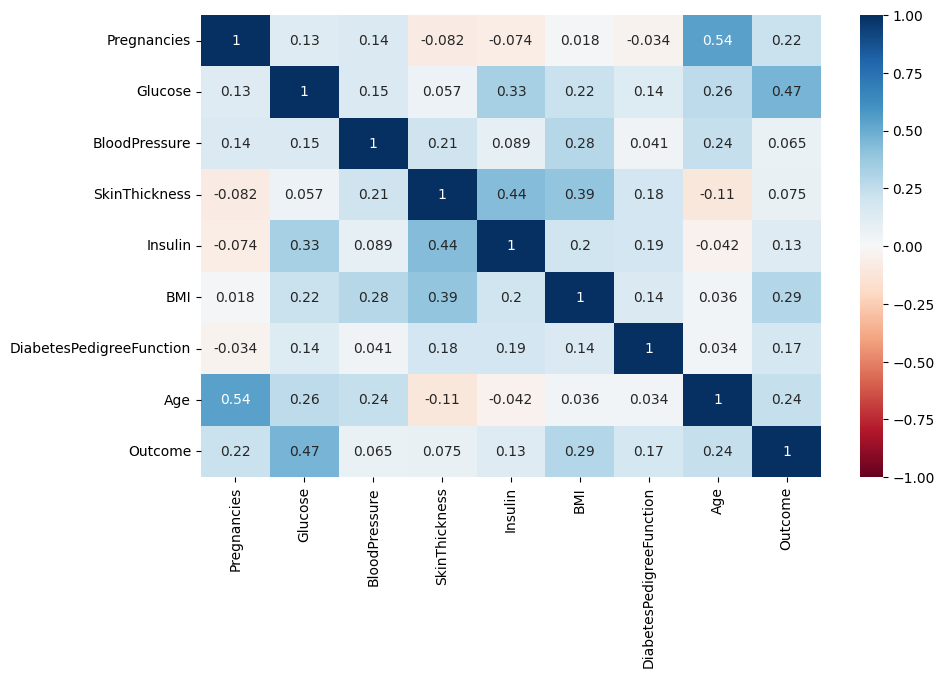

In [349]:
# Heatmap of the dataset
plt.figure(figsize=(10, 6))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True ,cmap='RdBu', vmin=-1, vmax=1)
plt.show()

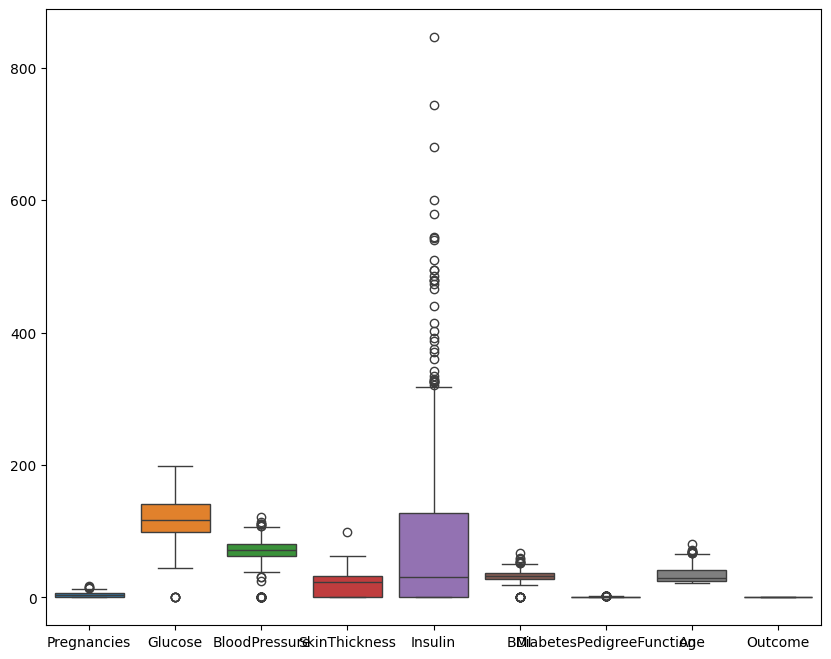

In [350]:
# Boxplot of the dataset
plt.figure(figsize=(10, 8))
sns.boxplot(data=data)
plt.show()

# Data Preproceesing

In [351]:
# Drop unnessary columns from the dataset (we know from the heatmap)
data = data.drop(["Insulin", "SkinThickness", "DiabetesPedigreeFunction", "BloodPressure"], axis=1)

In [352]:
cols = ['Glucose','BMI']

for col in cols:
    data[col] = data[col].replace(0, data[col].mean())

In [353]:
# Handling outliers
def remove_outliers(df, columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df   

data = remove_outliers(data,['Glucose', 'BMI'])

In [354]:
# Splitting the data and labels
X = data.drop(columns='Outcome',axis=1)
y = data['Outcome']

In [355]:
selected = SelectKBest(k=5)
X = selected.fit_transform(X, y)

c:\Users\Asmaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:783: UserWarning: k=5 is greater than n_features=4. All the features will be returned.
  warnings.warn(


In [356]:
# Splitting the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [357]:
# Standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ML models

In [382]:
models = {
    "SVM": svm.SVC(),
    "Logistic Regression": LogisticRegression(C=2, solver='liblinear'),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "Gradient Boosting" : GradientBoostingClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42)
}


In [383]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc_train = model.score(X_train, y_train)
    acc_test = accuracy_score(y_test, y_pred)
    
    results[name] = acc_test
    
    print(f"{name} Train Accuracy: {acc_train:.4f}")
    print(f"{name} Test Accuracy: {acc_test:.4f}\n")  

SVM Train Accuracy: 0.7747
SVM Test Accuracy: 0.7763

Logistic Regression Train Accuracy: 0.7664
Logistic Regression Test Accuracy: 0.8026

KNN Train Accuracy: 0.8043
KNN Test Accuracy: 0.8026

Gradient Boosting Train Accuracy: 0.8816
Gradient Boosting Test Accuracy: 0.7697

Decision Tree Train Accuracy: 1.0000
Decision Tree Test Accuracy: 0.6711

Random Forest Train Accuracy: 0.9474
Random Forest Test Accuracy: 0.7697



In [384]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Accuracy:", results[best_model])

clf = models[best_model]

Best Model: Logistic Regression
Accuracy: 0.8026315789473685


# Try The model

In [385]:
input_sample = (5,166,22.7,51)
input_sample = np.asarray(input_sample).reshape(1,-1)
std_data = scaler.transform(input_sample)

In [386]:
prediction = clf.predict(std_data)

In [387]:
if (prediction[0]==0):
    print("Person is not diabetic")
else:
    print("Person is diabetic")

Person is diabetic
